# k-nearest Neighbors (kNN)

KNN predicts a value or class by finding the K most similar data points (neighbors) and using them to decide the outcome.

* NumPy 1D vectors
* Column vectors could also be used
* Libraries used
- [x] Part 1 - Distance, Majority, Knn Prediction
- [x] Part 2 - Synthetic Data
- [x] Part 3 - Prediction Grid
- [x] Part 4 -
- [x] Part 5 -


## Function Distance
To calculate the distance between two vectors we can use trigonometry, where the hypotenuse is the distance.<br>

`np.sqrt()`<br>
`np.sum()`<br>
`np.pow(x, pow)`<br>

### Majority Vote (random)

`max(vote_counts)`<br>
`min(vote_counts)`<br>
`max(vote_counts.values())`<br>
`max(vote_counts.keys())`<br>
`random.choice`<br>
### Majority Vote (SciPy)
`import scipy.stats as ss`<br>
`ss.mstats.mode(x)`<br>

### Function Knn Prediction
`outcomes` is the class of the points.<br>

In [75]:
import numpy as np
import random
import matplotlib.pyplot as plt

def distance(p1,p2):
    """
    Find the distance between point p1 and p2
    :param p1: (x1,y2)
    :param p2: (x2,y2)
    :return: distance between points
     Example: distance(np.array([1,1]),np.array([4,4]))
    """

    np.power(p2 - p1, 2)
    return np.sqrt(np.sum(np.pow(p2 - p1, 2)))

def majority_vote(votes):
    """

    :param votes: Specify a list with votes.
    :return: The highest value and in case of tie, it returns a random vote between them.
    """

    vote_dict = {}
    for vote in votes:
        if vote in vote_dict:
            vote_dict[vote] += 1
        else:
            vote_dict[vote] = 1


    winner = []
    max_count = max(vote_dict.values())

    for vote, count in vote_dict.items():
        if count == max_count:
             winner.append(vote)


    return random.choice(winner) #in case of tie, it will take as random.

def majority_vote_sp(vote):
    """"
    :param vote: Vote

    """
    mode, count = ss.mstats.mode(vote)
    return mode

def find_near_neighbors(p,points, k = 2):

    """
    Find k nearest neighbors of point p
    :param p: Point in question
    :param points: Reference points
    :param k: How many nearest neighbors to return (2 as standard)
    :return: List of nearest neighbors by lower to higher

    """

    distances = np.zeros(points.shape[0]) #0 because I am looking for the rows at points.
    for i in range(len(distances)):
        distances[i] = distance(p,points[i])
        ind = np.argsort(distances)

    return ind[:k]

def knn_predict (p, points,outcomes, k = 2):
    ind = find_near_neighbors(p, points, k)
    return majority_vote(outcomes[ind])


### Part 1 - Test

1


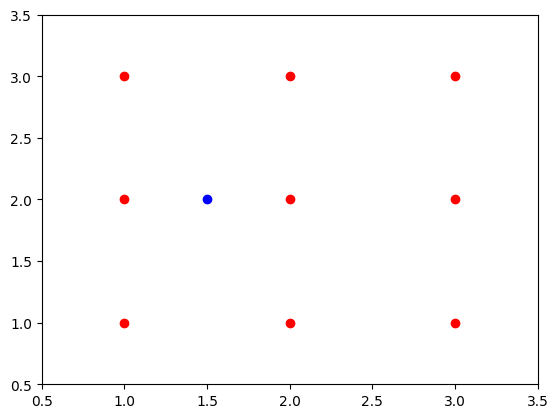

In [76]:
points = np.array([[1,1],[1,2],[1,3],[2,1],[2,2],[2,3],[3,1],[3,2],[3,3]])
outcomes = np.array([0,0,0,0,1,1,1,1,1])
p = np.array([1.5,2])

knn_predict = knn_predict (p,points,outcomes)
print(knn_predict)

plt.plot(points[:,0],points[:,1], 'ro')
plt.plot(p[0],p[1], 'bo')
plt.axis((0.5, 3.5, 0.5, 3.5))
plt.show()




## Synthetic Data
`ss.norm(mean,standard deviation)`<br>
mean = 0, standard deviation = 1 (standard normal distribution)<br>
`ss.norm().rvs(rows,colunms)`<br>
`np.repeat(0,1)`<br>
* Write a function to generate two class data points (0 and 1)
* Synthetic data is due the help of computer to produce it.
* bivariate, univariate<br>

### Statistics:
**Mean:** “Balance point of my data.” (spread evenly)<br>
**Deviation:** “how wide the bell curve is.” (1: normal) (0.1: Skinny) (5: Wide)<br>

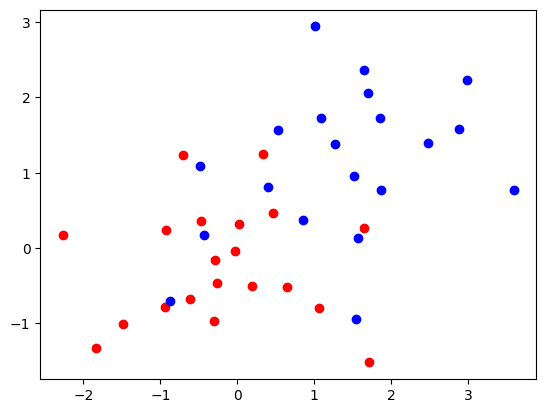

In [77]:
import scipy.stats as ss
import matplotlib.pyplot as plt

def generate_synthetic_data(n = 50):
    """
    Create two sets of points from a bivariate normal distribution
    :param n: amount of data from each class.
    :return: points and outcomes
    """


    xy0 = ss.norm(0,1).rvs((n,2)) #mean 0 values with orbit around it (will have class 0)
    xy1 = ss.norm(1,1).rvs((n,2)) #rsv with variable rows, for a bivariate  analysis

    points_synth_internal = np.concatenate((xy0, xy1), axis = 0)  #they will be concatenated on axis x

    #Way to do without xy0 and xy1:
    #points_synth_internal = np.concatenate(((ss.norm(0,1).rvs((n,2))),(ss.norm(1,1).rvs((n,2)))), axis = 0)

    #-------------------------------- Doing the same for the outcomes but with only classes 0,1
    outcomes_synth_internal = np.concatenate((np.repeat(0, n), np.repeat(1, n)))
    return points_synth_internal, outcomes_synth_internal

n = 20
(points_synth,outcomes_synth) = generate_synthetic_data(n)

plt.figure()
plt.plot(points_synth[:n,0],points_synth[:n,1], 'ro')
plt.plot(points_synth[n:,0],points_synth[n:,1], 'bo')

## Prediction grid
`meshgrid` takes two or more coordinate vectors (one with x and other with y), it returns matrices the first containing x values for each grid point and the second containing the y values for each grid point.<br>
`enumerate` Takes an iterable and returns a new iterable with tuples as elements, where the first index of each tuple is the index of the tuple in the iterable<br>
`print(enumerate.list)`<br>
`np.arrange` Creates regularly spaced values between the first and second argument, with spacing given in the third argument<br>

In [78]:
import numpy as np

def make_prediction_grid(predictors, outcomes, limits, h, k):
    """
    Classify each point of the prediction grid.
    :param predictors: the points for the system
    :param outcomes:
    :param limits: (x_min, x_max, y_min, y_max)
    :param h: Increment
    :param k:
    :return:
    """
    (x_min, x_max, y_min, y_max) = limits

    xs = np.arange(x_min, x_max, h)
    ys = np.arange(y_min, y_max, h)

    xx, yy = np.meshgrid(xs, ys)

    prediction_grid = np.zeros(xx.shape, dtype = int)
    for i,x in enumerate(xs):
        for j,y in enumerate(ys):
            p = np.array([x,y])
            prediction_grid[j,i] = knn_predict(p, predictors, outcomes, k)

    return xx, yy, prediction_grid

## Plot Prediction Grid

In [79]:
from matplotlib.colors import ListedColormap

def plot_prediction_grid (xx, yy, prediction_grid, filename):
    """
    Plot KNN predictions for every point on the grid.
    :param xx: limit x_min to x_max
    :param yy: limit y_min to y_max
    :param prediction_grid: function created before
    :param filename: name of the file to be saved
    :return:
    """

    background_colormap = ListedColormap (["hotpink","lightskyblue", "yellowgreen"])
    observation_colormap = ListedColormap (["red","blue","green"])

    plt.figure(figsize =(10,10))
    plt.pcolormesh(xx, yy, prediction_grid, cmap = background_colormap, alpha = 0.5)
    plt.scatter(predictors[:,0], predictors [:,1], c = outcomes, cmap = observation_colormap, s = 50)
    plt.xlabel('Variable 1'); plt.ylabel('Variable 2')
    plt.xticks(()); plt.yticks(())
    plt.xlim (np.min(xx), np.max(xx))
    plt.ylim (np.min(yy), np.max(yy))
    plt.savefig(filename)



## Sklearn IRIS dataset and KNeighborsClassifier
IRIS is **150 flowers** observed and for each one it was registered **Sepal length, sepal width, petal length, petal width**<br>
This is an example with 150 rows x 4 columns. **(Multivariate data)**

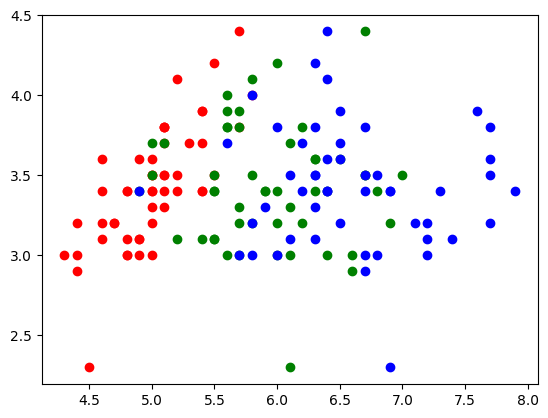

In [83]:
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier

iris = datasets.load_iris()
iris['data']

predictors = iris['data'][:,:2] # all rows but only column 0 and 1
outcomes = iris.target
plt.plot(predictors[outcomes==0][:,0], predictors[outcomes==0][:,1], 'ro')
plt.plot(predictors[outcomes==1][:,0], predictors[outcomes==0][:,1], 'go')
plt.plot(predictors[outcomes==2][:,0], predictors[outcomes==0][:,1], 'bo')


knn = KNeighborsClassifier(n_neighbors= 5)
knn.fit(predictors, outcomes)
sk_predictions = knn.predict(predictors)

print(sk_predictions.shape)
sk_predictions[0:10]